# E13 Polar Orthogonalization Vs Normalization Ablation

### Problem

This notebook separates polar/spectral orthogonalization from simpler norm-normalization effects. It tests whether Muon-family gains can be explained by update normalization alone, or whether exact/approximate polar directions add a distinct benefit.

### Metric And Function Definitions

The plots and tables use these diagnostics. They are defined here so symbols like `srank()` are not left implicit.

Let the singular values of a matrix $M$ be $\sigma_1\ge\sigma_2\ge\cdots\ge0$.

| name in notebook/code | definition | how to read it |
|---|---|---|
| `srank(M)` / `stable_rank(M)` | $\operatorname{srank}(M)=\lVert M\rVert_F^2/(\lVert M\rVert_{op}^2+\epsilon)=\sum_i\sigma_i^2/(\sigma_1^2+\epsilon)$ | Soft dimension based on energy; high means energy is spread over many singular directions. |
| `effective_rank(M)` | $\exp\{-\sum_i p_i\log p_i\}$, where $p_i=\sigma_i/(\sum_j\sigma_j+\epsilon)$ | Entropy rank; high means singular mass is evenly spread. |
| `nuclear_fro_ratio(M)` | $\lVert M\rVert_*^2/(\lVert M\rVert_F^2+\epsilon)=(\sum_i\sigma_i)^2/(\sum_i\sigma_i^2+\epsilon)$ | Another spectral-spread score; larger means less concentrated spectrum. |
| `condition_score` | mean `nuclear_fro_ratio(gradient)` divided by mean `stable_rank(activation/factor)` | Larger is the paper-style regime where spectral updates are predicted to help more. |
| `top_sv_error` | $\lVert \sigma_{1:k}(\widehat X)-\sigma_{1:k}(X^\star)\rVert_2/(\lVert\sigma_{1:k}(X^\star)\rVert_2+\epsilon)$ | Lower means leading singular values are recovered better. |
| `descent_alignment` / `grad_update_cosine` | $\langle -G,\Delta\rangle/(\lVert G\rVert_F\lVert\Delta\rVert_F+\epsilon)$ | Near 1 follows negative gradient; near 0 is orthogonal; negative is locally uphill. |
| `relative_step_size` | $\lVert\Delta\theta\rVert_F/(\lVert\theta\rVert_F+\epsilon)$, aggregated across parameter blocks | Size of the update relative to current parameter scale. |
| `balancedness(W_{1:K})` | average adjacent Gram mismatch $\lVert W_i^\top W_i-W_{i+1}W_{i+1}^\top\rVert_F/(\lVert W_i^\top W_i\rVert_F+\lVert W_{i+1}W_{i+1}^\top\rVert_F+\epsilon)$ | Lower means neighboring factors have more compatible scale/geometry. |
| `log_error_gap_vs_adam` / heatmap gap | $\log_{10}e_{method}-\log_{10}e_{Adam}$ | Negative favors the method; positive favors Adam. |


## Implementation Details: Skip Unless Modifying The Experiment

In [1]:
import math
import os
import pathlib
import sys
import time
from itertools import product

for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Documents/Workspace/MUONexperiment
torch   = 2.11.0


### Parameters And Runs

In [2]:
NOTEBOOK_ID = "E13 polar vs normalization"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon", "Muon-Exact", "Muon-NS-1", "Muon-Truncated", "Muon-RandSVD", "NormalizedSGD", "SpectralNormSGD", "LayerwiseNormalizedSGD", "Adam", "SGD"]
SEEDS = list(range(5))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 100

BASE_SPEC = dict(d=60, rank=5, lr=0.01, iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
                 diagnostic_every=1 if SMOKE_TEST else 20, early_stop=True, early_stop_min_steps=100,
                 early_stop_patience=20, early_stop_min_delta=1e-8, device_type=DEVICE.type, dtype_name=DTYPE_NAME)
SETTINGS = [
    dict(setting="MS-easy", problem="MatrixSensing", spectrum="hard-cutoff", kappa=1.0, m_multiplier=8, noise=0.0, dist="normal", init_scale=1e-2),
    dict(setting="MS-hard", problem="MatrixSensing", spectrum="exponential-decay", kappa=100.0, m_multiplier=4, noise=0.0, dist="normal", init_scale=1e-2),
    dict(setting="MF-standard", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-2, right_scale=1e-2),
    dict(setting="MF-imbalanced", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1.0),
]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([{**BASE_SPEC, **setting, "algo": algo, "seed": seed}
                     for setting in SETTINGS for algo in ALGOS for seed in SEEDS])
runs.insert(0, "run_id", range(len(runs)))
print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
runs=200, max_total_steps=20000


,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,kappa,m_multiplier,noise,dist,init_scale,algo,seed,factor_rank,left_scale,right_scale
0,0,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.0,8.0,0.0,normal,0.01,Muon,0,NaN,NaN,NaN
1,1,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.0,8.0,0.0,normal,0.01,Muon,1,NaN,NaN,NaN
2,2,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.0,8.0,0.0,normal,0.01,Muon,2,NaN,NaN,NaN
3,3,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.0,8.0,0.0,normal,0.01,Muon,3,NaN,NaN,NaN
4,4,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.0,8.0,0.0,normal,0.01,Muon,4,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.0,NaN,NaN,NaN,NaN,SGD,0,5.0,0.0001,1.0
196,196,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.0,NaN,NaN,NaN,NaN,SGD,1,5.0,0.0001,1.0
197,197,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.0,NaN,NaN,NaN,NaN,SGD,2,5.0,0.0001,1.0
198,198,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.0,NaN,NaN,NaN,NaN,SGD,3,5.0,0.0001,1.0


### Pseudocode

```text
for each selected MS/MF setting and optimizer:
    build the problem using repo problem constructors
    train while recording actual parameter updates
    compare recovery error, time per step, update effective rank, and descent alignment
```

### Worker Definition

In [3]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_generator(seed, device):
    try:
        return torch.Generator(device=device).manual_seed(int(seed))
    except Exception:
        return torch.Generator().manual_seed(int(seed))


def randn(shape, seed, device, dtype):
    shape = tuple(int(dim) for dim in shape)
    return torch.randn(shape, generator=make_generator(seed, device), device=device, dtype=dtype)


def make_optimizer(algo, params, lr, rank=None):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-Exact":
        return optimizers.MuonExact(params, lr=lr, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-5":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, variant="randsvd", rank=rank)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="spectral", momentum=0.0)
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr)
    raise ValueError(f"unknown optimizer: {algo}")


def nuclear_fro_ratio(matrix, epsilon=1e-12):
    singular_values = torch.linalg.svdvals(matrix.detach())
    numerator = singular_values.sum().square()
    denominator = singular_values.square().sum().clamp_min(epsilon)
    return float((numerator / denominator).detach().cpu())


def relative_update_diagnostics(params_before, params_after, gradients):
    updates = [after.detach() - before.detach() for before, after in zip(params_before, params_after)]
    return {
        "descent_alignment": util.diagnostics.descent_alignment(gradients, updates),
        "relative_step_size": util.diagnostics.relative_step_size(params_before, updates),
        **util.diagnostics.aggregate_matrix_diagnostics(updates, prefix="update"),
        **util.diagnostics.aggregate_matrix_diagnostics(gradients, prefix="grad"),
    }


def summarize_last_rows(runs, group_columns):
    ordered = runs.sort_values(["run_id", "step"])
    return ordered.groupby(group_columns, as_index=False, observed=True).tail(1).reset_index(drop=True)

def single_run(run):
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)
    device = torch.device(run["device_type"])
    params = []
    if run["problem"] == "MatrixSensing":
        problem = problems.MatrixSensing.make_matrix_sensing_problem(
            run["d"], run["rank"], noise=run["noise"], dist=run["dist"], spectrum=run["spectrum"], kappa=run["kappa"],
            seed=run["seed"], device=device, dtype=dtype, m_multiplier=run["m_multiplier"])
        x = (run["init_scale"] * randn((run["d"], run["d"]), run["seed"] + 10, device, dtype)).requires_grad_(True)
        params = [x]
        def current_loss(): return problem.loss(x)
        def estimate(): return x
        opt_rank = run["rank"]
    else:
        problem = problems.MatrixFactorization.make_matrix_factorization_problem(
            run["d"], run["rank"], spectrum=run["spectrum"], kappa=run["kappa"], seed=run["seed"], device=device, dtype=dtype,
            factor_rank=run["factor_rank"], num_factors=int(run.get("num_factors", 10)))
        factor_inits = problems.MatrixFactorization.initialize_factor_chain(
            int(run["d"]), int(run["factor_rank"]), seed=int(run["seed"]) + 10, device=device, dtype=dtype,
            num_factors=int(run.get("num_factors", 10)),
            left_scale=float(run["left_scale"]), right_scale=float(run["right_scale"]),
        )
        factors = [factor.requires_grad_(True) for factor in factor_inits]
        params = factors
        def current_loss(): return problem.loss(*factors)
        def estimate(): return problem.estimate(*factors)
        opt_rank = run["rank"]
    opt = make_optimizer(run["algo"], params, run["lr"], rank=opt_rank)
    initial_loss = float(current_loss().detach().cpu())
    best_loss = initial_loss
    wait = 0
    rows = []
    start = time.perf_counter()
    stop_reason = "max_steps"
    for step in range(int(run["iters"]) + 1):
        do_diag = (step == 0) or (step == run["iters"]) or (step % int(run["diagnostic_every"]) == 0)
        if do_diag:
            rows.append({**run, "step": step, "initial_loss": initial_loss, "loss": float(current_loss().detach().cpu()),
                         "best_loss": best_loss, "recovery_error": util.diagnostics.relative_matrix_error(estimate(), problem.target),
                         "top_sv_error": util.diagnostics.top_singular_value_error(estimate(), problem.target, k=run["rank"]),
                         "elapsed_s": time.perf_counter() - start, "stop_reason": stop_reason})
        if step == run["iters"]:
            break
        loss = current_loss()
        loss.backward()
        params_before = [p.detach().clone() for p in params]
        grads = [p.grad.detach().clone() for p in params]
        opt.step()
        params_after = [p.detach().clone() for p in params]
        for p in params:
            p.grad = None
        if do_diag and rows:
            rows[-1].update(relative_update_diagnostics(params_before, params_after, grads))
        current = float(current_loss().detach().cpu())
        if best_loss - current > run["early_stop_min_delta"]:
            best_loss = current
            wait = 0
        else:
            wait += 1
        if run["early_stop"] and step >= run["early_stop_min_steps"] and wait >= run["early_stop_patience"]:
            stop_reason = "early_stop"
            break
    return pd.DataFrame(rows)


## Results

In [4]:
runs = util.run_experiments(runs, single_run, num_workers=NUM_WORKERS, backend=JOBLIB_BACKEND,
                            algo_order=ALGOS, sort_columns=("run_id", "step"), desc=NOTEBOOK_ID)
IPython.display.display(runs)


E13 polar vs normalization:   0%|          | 0/200 [00:00<?, ?run/s]

E13 polar vs normalization:   0%|          | 1/200 [00:09<32:31,  9.81s/run]

E13 polar vs normalization:   4%|▍         | 9/200 [00:13<03:57,  1.24s/run]

E13 polar vs normalization:   8%|▊         | 17/200 [00:16<02:15,  1.35run/s]

E13 polar vs normalization:  12%|█▎        | 25/200 [00:19<01:39,  1.76run/s]

...

E13 polar vs normalization:  44%|████▍     | 89/200 [00:34<00:22,  4.88run/s]

E13 polar vs normalization:  50%|█████     | 100/200 [00:35<00:16,  6.15run/s]

E13 polar vs normalization:  80%|████████  | 161/200 [00:36<00:02, 18.50run/s]

E13 polar vs normalization: 100%|██████████| 200/200 [00:36<00:00,  5.45run/s]

,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,descent_alignment,relative_step_size,update_fro_norm,update_op_norm,update_effective_rank,update_stable_rank,grad_fro_norm,grad_op_norm,grad_effective_rank,grad_stable_rank
0,0,60,5,0.01,100,20,True,100,20,1.000000e-08,...,0.794383,1.176039e-01,0.069870,1.175185e-02,58.141815,35.348197,3.679090,1.231798,43.655186,8.920760
1,0,60,5,0.01,100,20,True,100,20,1.000000e-08,...,0.586418,5.357273e-02,0.066991,1.199672e-02,58.208999,31.182719,1.092687,0.391462,42.262788,7.791336
2,0,60,5,0.01,100,20,True,100,20,1.000000e-08,...,0.392543,3.819884e-02,0.070678,1.163816e-02,58.998479,36.880333,0.440847,0.114173,47.253353,14.909122
3,0,60,5,0.01,100,20,True,100,20,1.000000e-08,...,0.264062,3.262561e-02,0.067886,1.196981e-02,58.866200,32.164844,0.223398,0.056449,47.783545,15.662133
4,0,60,5,0.01,100,20,True,100,20,1.000000e-08,...,0.323574,3.180667e-02,0.067432,1.135023e-02,58.913546,35.295415,0.143673,0.035801,47.609976,16.105031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,199,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.000000,6.392415e-07,0.000011,8.291371e-07,2.838383,0.188056,0.001134,0.000083,2.838383,0.271914
1196,199,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.000000,6.370881e-07,0.000011,8.272003e-07,2.711781,0.188053,0.001130,0.000083,2.711781,0.341801
1197,199,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.000000,6.349429e-07,0.000011,8.253981e-07,2.668777,0.188053,0.001126,0.000083,2.668777,0.457765
1198,199,60,5,0.01,100,20,True,100,20,1.000000e-08,...,1.000000,6.328059e-07,0.000011,8.236580e-07,2.640198,0.188057,0.001122,0.000082,2.640198,0.618405


### Individual Loss Curves

**What this plot is:** raw training-loss trajectories comparing polar Muon variants against normalization-only baselines.

- **One line:** one full run, meaning one `(setting, optimizer variant, seed)` combination.
- **Panel:** benchmark setting, such as direct Matrix Sensing or ten-factor Matrix Factorization.
- **Color:** optimizer or variant identity.
- **X-axis:** optimizer step.
- **Y-axis:** training loss on a log scale; lower is better.
- **How to read it:** if normalization-only colors track Muon-family colors closely, normalization may explain most of the benefit. If exact/NS Muon drops lower than all normalization baselines, polar geometry is adding something beyond scale normalization.


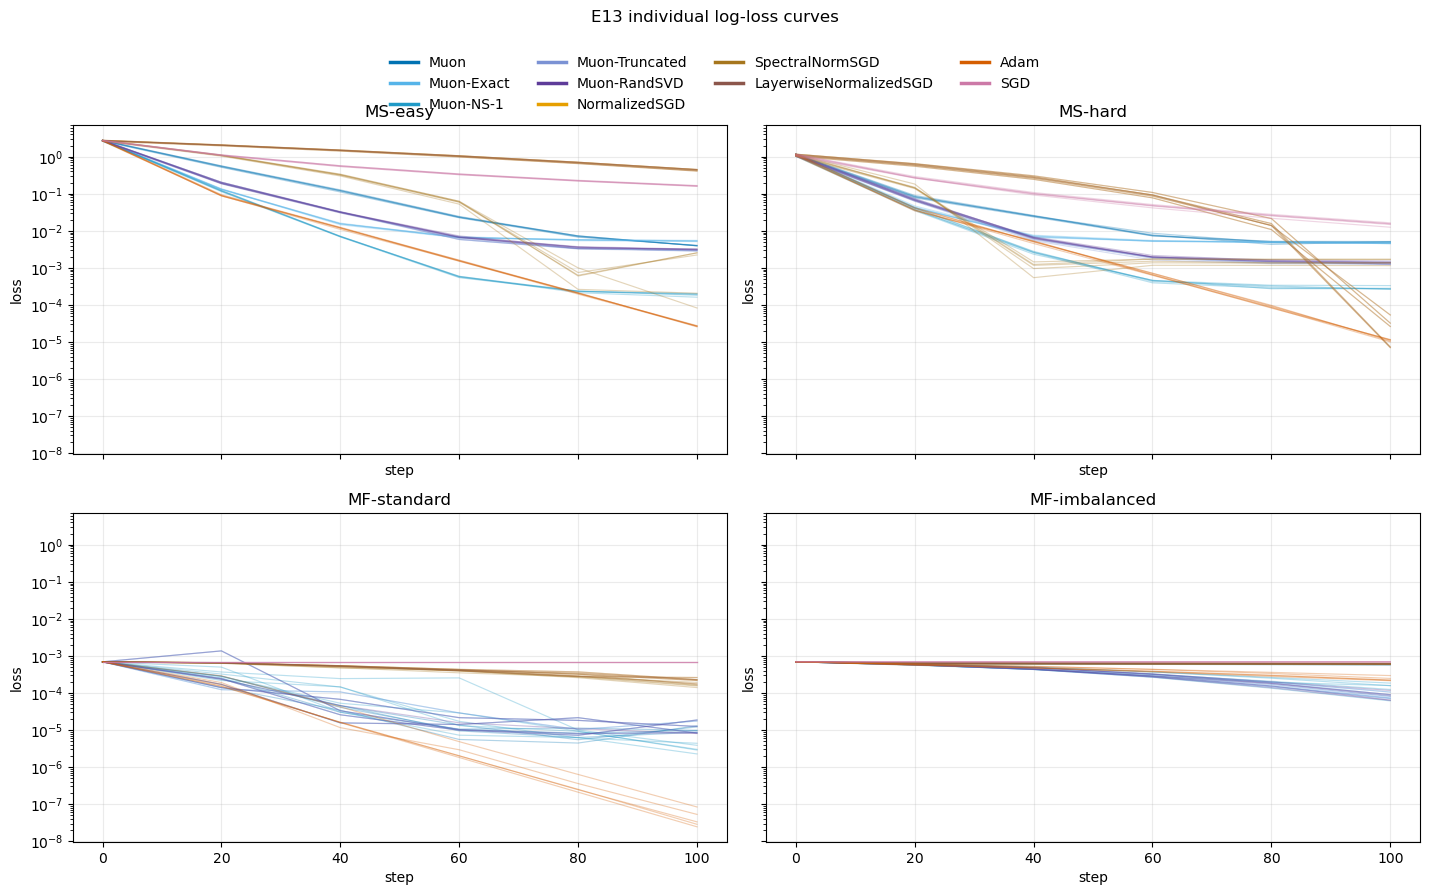

In [5]:
import plotting
from matplotlib.lines import Line2D


def plot_individual_loss_curves(frame, panel_column, *, panel_order=None, title_prefix="Individual loss curves"):
    plot_frame = frame[np.isfinite(frame["loss"])].copy()
    if plot_frame.empty:
        print("No finite loss values to plot.")
        return None, None
    plot_frame["loss_plot"] = plot_frame["loss"].clip(lower=1e-300)
    panels = list(panel_order) if panel_order is not None else sorted(plot_frame[panel_column].dropna().unique())
    ncols = min(2, max(1, len(panels)))
    nrows = math.ceil(len(panels) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.2 * ncols, 4.2 * nrows), sharex=True, sharey=True, squeeze=False)
    axes_flat = axes.ravel()
    for ax, panel in zip(axes_flat, panels):
        sub = plot_frame[plot_frame[panel_column] == panel].sort_values(["run_id", "step"])
        run_count = max(1, sub["run_id"].nunique())
        alpha = max(0.04, min(0.30, 18.0 / run_count))
        for _, group in sub.groupby("run_id", observed=True, sort=False):
            algo = str(group["algo"].iloc[0])
            ax.plot(
                group["step"],
                group["loss_plot"],
                color=plotting.algorithm_color(algo),
                linewidth=0.85,
                alpha=alpha,
            )
        ax.set_title(str(panel))
        ax.set_xlabel("step")
        ax.set_ylabel("loss")
        ax.set_yscale("log")
        ax.grid(alpha=0.25)
    for ax in axes_flat[len(panels):]:
        ax.axis("off")
    algos = [algo for algo in ALGOS if algo in set(plot_frame["algo"].astype(str))]
    handles = [Line2D([0], [0], color=plotting.algorithm_color(algo), linewidth=2.5, label=algo) for algo in algos]
    if handles:
        fig.legend(handles=handles, loc="upper center", ncol=min(4, len(handles)), bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.suptitle(title_prefix, y=1.06 if handles else 1.02)
    fig.tight_layout()
    return fig, axes

fig, axes = plot_individual_loss_curves(runs, "setting", panel_order=[setting["setting"] for setting in SETTINGS], title_prefix="E13 individual log-loss curves")
plt.show()


### Figure Discussion: Individual Loss Curves

This figure compares mechanisms during training. Each panel is one benchmark setting, each faint line is one seed/run, and color is the optimizer variant. Muon-family colors represent polar or approximate-polar updates; normalization-baseline colors represent updates that mostly control step scale. If the normalization colors overlap the Muon-family colors, then simple normalization may explain the behavior. If exact or Newton-Schulz Muon colors drop lower than every normalization baseline in the same panel, that is evidence that polar geometry adds something beyond normalization.


### Result Tables

**What this table is:** final accuracy and cost summary for each setting and optimizer variant.

- **median_recovery:** lower is better; primary accuracy metric.
- **median_top_sv_error:** lower means the leading singular values match the target better.
- **median_time:** per-step cost proxy; lower is cheaper.
- **median_update_rank / cosine:** update-geometry diagnostics.
- **How to read it:** first compare recovery within the same setting, then use cost and update diagnostics to explain whether the win is practical or merely more expensive.


In [6]:
run_summary = summarize_last_rows(runs, ["run_id"])
summary = run_summary.groupby(["setting", "algo"], as_index=False, observed=True).agg(
    median_recovery=("recovery_error", "median"), median_top_sv_error=("top_sv_error", "median"),
    median_update_effective_rank=("update_effective_rank", "median"), median_alignment=("descent_alignment", "median"),
    median_step_size=("relative_step_size", "median"), median_time=("elapsed_s", "median"))
IPython.display.display(summary.sort_values(["setting", "median_recovery"]))


,setting,algo,median_recovery,median_top_sv_error,median_update_effective_rank,median_alignment,median_step_size,median_time
3,MF-imbalanced,Muon-Exact,0.340825,0.140342,NaN,NaN,NaN,0.097572
6,MF-imbalanced,Muon-Truncated,0.340825,0.140342,NaN,NaN,NaN,0.108409
5,MF-imbalanced,Muon-RandSVD,0.348980,0.122022,NaN,NaN,NaN,0.147347
4,MF-imbalanced,Muon-NS-1,0.476842,0.246162,NaN,NaN,NaN,0.108954
0,MF-imbalanced,Adam,0.568072,0.429255,NaN,NaN,NaN,0.078937
2,MF-imbalanced,Muon,0.918688,0.683375,NaN,NaN,NaN,0.147925
9,MF-imbalanced,SpectralNormSGD,0.925366,0.732082,NaN,NaN,NaN,0.085483
1,MF-imbalanced,LayerwiseNormalizedSGD,0.935334,0.750040,NaN,NaN,NaN,0.071820
7,MF-imbalanced,NormalizedSGD,0.935334,0.750040,NaN,NaN,NaN,0.078990
8,MF-imbalanced,SGD,0.998499,0.992974,NaN,NaN,NaN,0.053640


### Accuracy-Cost Scatter

**What this plot is:** a Pareto-style view of accuracy versus computational cost.

- **One point:** one optimizer's median result in one setting.
- **X-axis:** median time per optimizer step on a log scale; farther left is cheaper.
- **Y-axis:** median recovery error on a log scale; lower is more accurate.
- **Best region:** lower-left.
- **How to read it:** a method is compelling only if it moves down without moving too far right. A point that is low but far right is accurate but expensive.


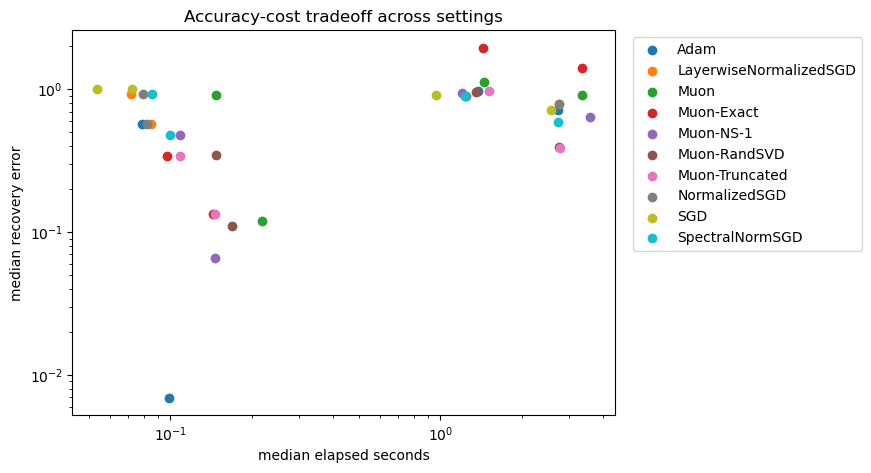

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for algo, group in summary.groupby("algo", observed=True):
    ax.scatter(group["median_time"], group["median_recovery"], label=algo)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("median elapsed seconds")
ax.set_ylabel("median recovery error")
ax.set_title("Accuracy-cost tradeoff across settings")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


### Figure Discussion: Accuracy-Cost Scatter

Each point is one optimizer's median performance in one setting. The x-coordinate is median elapsed time per step, so left means cheaper. The y-coordinate is median recovery error, so lower means more accurate. The lower-left corner is the best region. A point low on the plot but far to the right is accurate but expensive. A point far left but high is cheap but inaccurate. This figure is there to prevent over-interpreting an accurate method that is much slower per step.


### Normalization Baselines Vs Polar Variants

**What this plot is:** a within-setting ranking of optimizer variants by recovery error.

- **One bar:** one optimizer or variant.
- **Y-axis:** median recovery error on a log scale; shorter bars are better.
- **How to read it:** compare the best polar variants (`Muon-Exact`, `Muon-NS-*`) against normalization-only baselines (`NormalizedSGD`, `SpectralNormSGD`, `LayerwiseNormalizedSGD`). If their bars are similar, normalization explains much of the effect. If polar bars are clearly shorter, polar geometry matters.


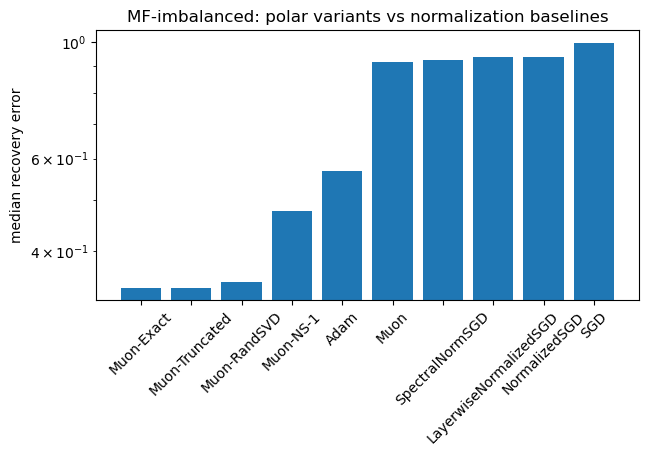

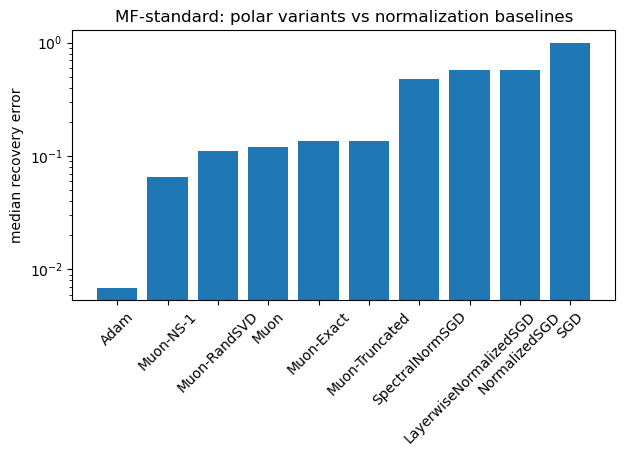

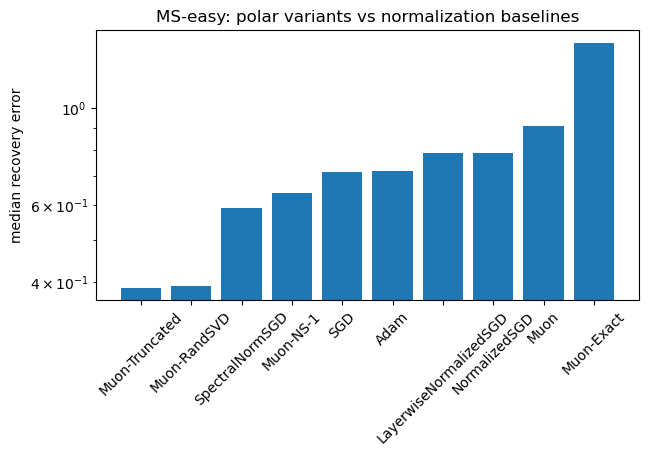

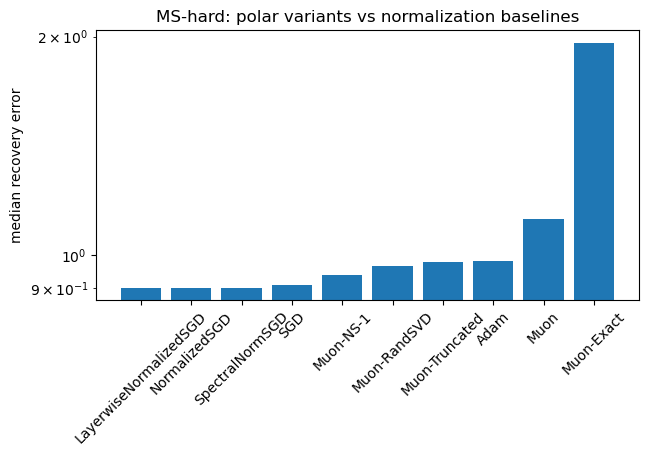

In [8]:
for setting in sorted(summary["setting"].unique()):
    sub = summary[summary["setting"] == setting].sort_values("median_recovery")
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(sub["algo"], sub["median_recovery"])
    ax.set_yscale("log")
    ax.set_title(f"{setting}: polar variants vs normalization baselines")
    ax.set_ylabel("median recovery error")
    ax.tick_params(axis="x", rotation=45)
    plt.show()


### Figure Discussion: Normalization Baselines Vs Polar Variants

Each generated bar chart fixes one setting and ranks methods by median recovery error. The bar height is error on a log scale, so shorter is better. The comparison to make is not just Muon versus Adam; it is polar variants versus normalization-only baselines. If `NormalizedSGD`, `SpectralNormSGD`, or `LayerwiseNormalizedSGD` has bars as short as Muon-family methods, the result points to normalization as the main mechanism. If `Muon-Exact` or `Muon-NS-*` is clearly shorter, polar geometry is doing extra work.


### Reading The Result

Read E13 as a mechanism ablation, not just a leaderboard. The key comparison is Muon-family polar variants versus normalization-only baselines under the same settings.

If normalization baselines match Muon-family methods, the effect is likely explained by norm geometry. If Muon-Exact or Muon-NS-1 beats all normalization baselines in a setting, that is evidence for a distinct polar/spectral mechanism.


### Hypothesis Verdict Table

| hypothesis | evidence | supported? | caveat |
|---|---|---|---|
| Polar orthogonalization should be separable from normalization-only effects. | The notebook compares Muon-family polar variants against Frobenius, spectral, and layerwise normalization baselines. | Partial | Several regimes are explained well by normalization baselines, so polar geometry is not the only mechanism. |
| Cost must be considered alongside recovery. | The accuracy-cost scatter places median recovery against median time per step for each method. | Yes | Wall-clock timing is local to this implementation and hardware. |
